# Verify variants — is the input what we think it is?

Analysis, not pipeline. Checks the artifacts the chain produced, across all five gene-set variants,
before any conclusion is drawn from them.

| | |
|---|---|
| **reads** | all five variants' raw, embedding and targets h5ads |
| | its own cached sweep and per-cell counts, regenerated rather than reused |
| **writes** | `outputs/embeddings/` — `variants.png`, the two UMAPs, `hvg_sweep_auc.csv` + curve |

**Why this exists separately from the pipeline's own guards.** Each step asserts its own
preconditions, but nothing checks the *result* across variants: that cells stay aligned, that gene
sets nest, that the two representations rest on the same filter. Those are properties of the set of
artifacts, not of any one step.

⚠️ **§9 mixes variants built by different code** unless all five were rebuilt together. Its x-axis is
gene count; if the points also differ in code version, no trend can be read off the curve.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp

import sys

ROOT = next(q for q in [Path.cwd(), *Path.cwd().parents] if (q / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.layout import DEFAULT_CTRP_SCORE, PipelinePaths, targets_filename

# Derived, not hardcoded (12.08.2026). This was an absolute /Users/... path, so the notebook ran
# on exactly one machine; layout.py is the path contract every other stage already uses.
SCORE = DEFAULT_CTRP_SCORE
DATA_ROOT = PipelinePaths.build(None, 'hvg5000', SCORE).processed_dir.parent
VARIANTS = ['hvg5000', 'all_genes']
FILES = {
    'convert':    'SCP542_CCLE.h5ad',
    'embeddings': 'SCP542_CCLE_scGPT_human_embeddings.h5ad',
    # targets_filename() appends the score -- the bare '..._with_targets.h5ad' literal that
    # was here has not been written by the pipeline since 11.08.2026.
    'targets':    targets_filename(SCORE),
}
TARGETS = FILES['targets']
SEED = 42

def load(variant, stage, backed='r'):
    return sc.read_h5ad(DATA_ROOT / variant / FILES[stage], backed=backed)

## 1 · Gene-count flow per variant

| | |
|---|---|
| **out** | distributed → HVG-filtered → scGPT in-vocabulary, per variant |

Where each gene is lost, in order, so a drop can be attributed to the filter or to the vocabulary
rather than to "preprocessing".

In [2]:
rows = []
for v in VARIANTS:
    g = {s: load(v, s).n_vars for s in FILES}
    rows.append({'variant': v, 'convert (HVG)': g['convert'],
                 'embeddings (post-OOV)': g['embeddings'], 'targets': g['targets'],
                 'OOV dropped': g['convert'] - g['embeddings']})
pd.DataFrame(rows).set_index('variant')

,convert (HVG),embeddings (post-OOV),targets,OOV dropped
variant,,,,
hvg5000,5000,4765,4765,235
all_genes,22722,21332,21332,1390


## 2 · Why scGPT drops genes

| | |
|---|---|
| **out** | the OOV breakdown per variant |

Separates true absence from the vocabulary from loss to symbol vintage — the second is a fixable
defect and is quantified in `gene_symbol_rescue`.

In [3]:
for v in VARIANTS:
    emb = load(v, 'embeddings')
    if 'id_in_vocab' in emb.var.columns:
        iv = emb.var['id_in_vocab'].astype(int)
        print(f'{v}: in-vocab (id>=0) = {(iv >= 0).sum()},  OOV (== -1) = {(iv < 0).sum()}')
    else:
        print(f'{v}: embeddings already subset to in-vocab genes -> n_vars = {emb.n_vars}')

hvg5000: in-vocab (id>=0) = 4765,  OOV (== -1) = 0
all_genes: in-vocab (id>=0) = 21332,  OOV (== -1) = 0


## 3 · Cell alignment across files

| | |
|---|---|
| **out** | whether `obs_names` match, in order, across raw / embeddings / targets |

**Why order and not membership.** Every downstream array is indexed positionally — `obsm`, the
per-cell prediction arrays, the masks. A set-equal but differently ordered file would misalign every
one of them without raising.

In [4]:
for v in VARIANTS:
    a, b, c = load(v, 'convert'), load(v, 'embeddings'), load(v, 'targets')
    ok = np.array_equal(a.obs_names, b.obs_names) and np.array_equal(b.obs_names, c.obs_names)
    print(f'{v}: convert == embeddings == targets cell order -> {ok}  (n_cells = {c.n_obs})')

hvg5000: convert == embeddings == targets cell order -> True  (n_cells = 53513)
all_genes: convert == embeddings == targets cell order -> True  (n_cells = 53513)


## 4 · What `.X` holds, and where the representations come from

| | |
|---|---|
| **out** | the dtype, scale and provenance of `.X`, `X_pca` and `X_scGPT` per variant |

`.X` is CPM at every stage — never re-normalised. `X_pca` is fitted on the convert counts, `X_scGPT`
on the embedding file after OOV genes are dropped. The point of the table is that both rest on the
same single gene filter, which is what makes the comparison one of representations.

In [5]:
for v in VARIANTS:
    t = load(v, 'targets', backed=None)
    X = t.X
    Xd = X[:200].toarray() if sp.issparse(X) else np.asarray(X[:200])
    kind = 'CPM (raw-ish)' if Xd.max() > 100 else 'log-normalized'
    print(f'{v}:')
    print(f'  .X genes={t.n_vars}  max={Xd.max():.1f}  mean row-sum={Xd.sum(1).mean():,.0f}  -> {kind}')
    print(f'  X_scGPT={t.obsm["X_scGPT"].shape}  X_pca={t.obsm["X_pca"].shape}'
          f'  (X_pca built from {load(v, "convert").n_vars} convert genes)')

hvg5000:
  .X genes=4765  max=90079.0  mean row-sum=320,777  -> CPM (raw-ish)
  X_scGPT=(53513, 512)  X_pca=(53513, 512)  (X_pca built from 5000 convert genes)
all_genes:
  .X genes=21332  max=90079.0  mean row-sum=988,895  -> CPM (raw-ish)
  X_scGPT=(53513, 512)  X_pca=(53513, 512)  (X_pca built from 22722 convert genes)


## 5 · `hvg5000` against `all_genes`

In [6]:
hvg_conv = set(load('hvg5000', 'convert').var_names)
hvg_emb  = set(load('hvg5000', 'embeddings').var_names)
all_conv = set(load('all_genes', 'convert').var_names)
all_emb  = set(load('all_genes', 'embeddings').var_names)
print(f'HVG-5000 selected:                  {len(hvg_conv)}')
print(f'  in scGPT vocab (embedded):        {len(hvg_emb)}  ({len(hvg_conv - hvg_emb)} OOV)')
print(f'Full transcriptome:                 {len(all_conv)}')
print(f'  in scGPT vocab (embedded):        {len(all_emb)}  ({len(all_conv - all_emb)} OOV)')

HVG-5000 selected:                  5000
  in scGPT vocab (embedded):        4765  (235 OOV)
Full transcriptome:                 22722
  in scGPT vocab (embedded):        21332  (1390 OOV)


## 6 · Cross-variant embedding similarity

| | |
|---|---|
| **out** | per-cell agreement between the same representation built on different gene sets |

How much the representation moves when the gene set changes. High agreement means the extra genes
carry little that the encoder uses; low agreement means the gene set is a real degree of freedom and
§9's sweep is measuring something.

In [7]:
h = load('hvg5000', 'targets', backed=None)
a = load('all_genes', 'targets', backed=None)
Xh, Xa = np.asarray(h.obsm['X_scGPT']), np.asarray(a.obsm['X_scGPT'])
assert np.array_equal(h.obs_names, a.obs_names)
cos = (Xh * Xa).sum(1) / (np.linalg.norm(Xh, axis=1) * np.linalg.norm(Xa, axis=1) + 1e-9)
print(f'identical? {np.array_equal(Xh, Xa)} | max|diff|={np.abs(Xh-Xa).max():.3f} '
      f'| mean|diff|={np.abs(Xh-Xa).mean():.3f}')
print(f'per-cell cosine sim (filtered vs non-filtered X_scGPT): '
      f'mean={cos.mean():.3f}  min={cos.min():.3f}  max={cos.max():.3f}')

identical? False | max|diff|=0.204 | mean|diff|=0.014
per-cell cosine sim (filtered vs non-filtered X_scGPT): mean=0.918  min=0.697  max=0.975


## 7 · UMAP — PCA against scGPT

| | |
|---|---|
| **out** | `umap_cancertype_pca_vs_scgpt.png` |

Descriptive only. Coloured by cancer type and by one panel drug's response.

**Why response is shown on the same cells.** A representation can separate tissues beautifully and
carry nothing about drug response; showing both colourings on one embedding makes that distinction
visible instead of leaving it to be assumed.

In [8]:
PANELS = [
    ('hvg5000', 'X_pca',   'hvg5000 (filtered)\nPCA'),
    ('hvg5000', 'X_scGPT', 'hvg5000 (filtered)\nscGPT'),
    ('all_genes', 'X_pca',   'all_genes (non-filtered)\nPCA'),
    ('all_genes', 'X_scGPT', 'all_genes (non-filtered)\nscGPT'),
]
adatas = {v: load(v, 'targets', backed=None) for v in VARIANTS}
umaps = {}
for variant, rep, _ in PANELS:
    print('UMAP', variant, rep, '...')
    ad = adatas[variant]
    nk = f'nn_{rep}'
    sc.pp.neighbors(ad, use_rep=rep, random_state=SEED, key_added=nk)
    sc.tl.umap(ad, random_state=SEED, neighbors_key=nk)
    umaps[(variant, rep)] = ad.obsm['X_umap'].copy()

UMAP hvg5000 X_pca ...


/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


UMAP hvg5000 X_scGPT ...
UMAP all_genes X_pca ...


/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


UMAP all_genes X_scGPT ...


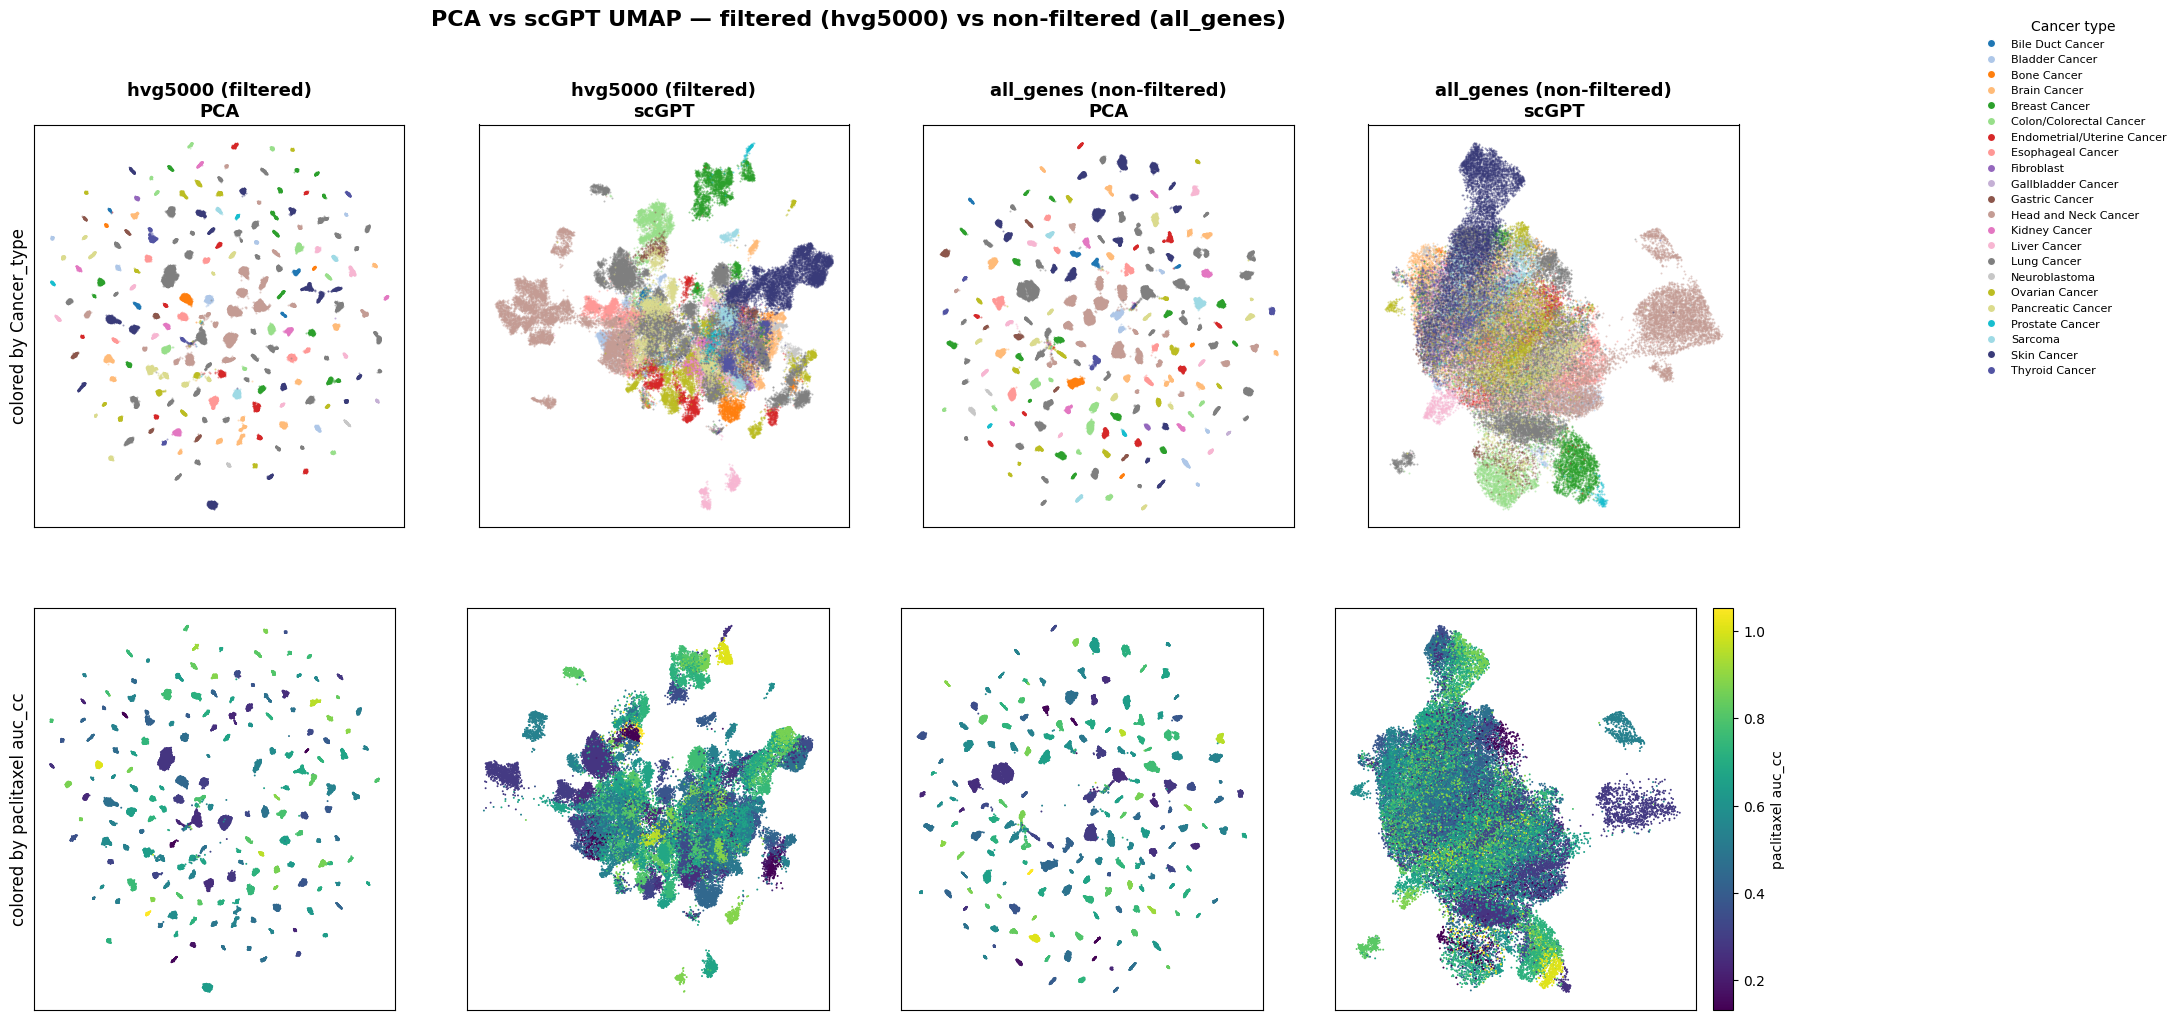

In [9]:
ref = adatas['hvg5000']
cancer = ref.obs['Cancer_type'].astype('category')
cats = list(cancer.cat.categories)
# Was obs['viability_paclitaxel'] until 13.08.2026 (Gate 5). That column is a leftover of the
# retired single-task paclitaxel progression and NOTHING IN scripts/ WRITES IT ANY MORE, so the
# rebuilt h5ads do not carry it and this cell raised KeyError. Paclitaxel is one of the eleven panel
# drugs, so the same quantity is available on the CURRENT target: its column of Y_ctrp, which is the
# line's auc_cc broadcast to that line's cells. The figure keeps its meaning and gains the target the
# project actually trains on -- but it is a DIFFERENT MEASURE from the old viability, so the panel is
# relabelled rather than silently reinterpreted.
_drugs = list(ref.uns['ctrp_drugs'])
_j = _drugs.index('paclitaxel')
_obs_mask = np.asarray(ref.obsm['M_ctrp'], dtype=bool)[:, _j]
via = np.where(_obs_mask, np.asarray(ref.obsm['Y_ctrp'], dtype=float)[:, _j], np.nan)
palette = list(plt.get_cmap('tab20').colors) + list(plt.get_cmap('tab20b').colors)
colors = {c: palette[i % len(palette)] for i, c in enumerate(cats)}

fig, axes = plt.subplots(2, 4, figsize=(22, 11.5))
sca = None
for j, (variant, rep, label) in enumerate(PANELS):
    U = umaps[(variant, rep)]
    ax = axes[0, j]
    for c in cats:
        m = cancer.values == c
        ax.scatter(U[m, 0], U[m, 1], s=2, alpha=0.5, color=colors[c], linewidths=0)
    ax.set_title(label, fontsize=13, fontweight='bold'); ax.set_xticks([]); ax.set_yticks([])
    ax = axes[1, j]
    sca = ax.scatter(U[:, 0], U[:, 1], s=2, c=via, cmap='viridis', linewidths=0)
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel('colored by Cancer_type', fontsize=12)
axes[1, 0].set_ylabel('colored by paclitaxel auc_cc', fontsize=12)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[c], markersize=6, label=c) for c in cats]
fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.005, 0.98), fontsize=8, title='Cancer type', frameon=False)
fig.colorbar(sca, ax=list(axes[1, :]), fraction=0.015, pad=0.01, label='paclitaxel auc_cc')
fig.suptitle('PCA vs scGPT UMAP — filtered (hvg5000) vs non-filtered (all_genes)', fontsize=16, fontweight='bold')
OUT_EMB = ROOT / 'notebooks' / 'outputs' / 'embeddings'   # resolved, not cwd-relative (13.08.2026)
OUT_EMB.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_EMB / "variants.png")
plt.show()

## 8 · Cancer-type UMAPs — tissue bias

| | |
|---|---|
| **out** | `umap_sweep_cancertype.png` |

Whether either representation organises cells primarily by tissue. Relevant because the split is by
cell line and the panel spans tissues: a representation that encodes mostly tissue would predict the
line effect well and drug-specific response badly, which is the failure mode DrEval's normalization
is built to expose.

### 8a · Headline panel

/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


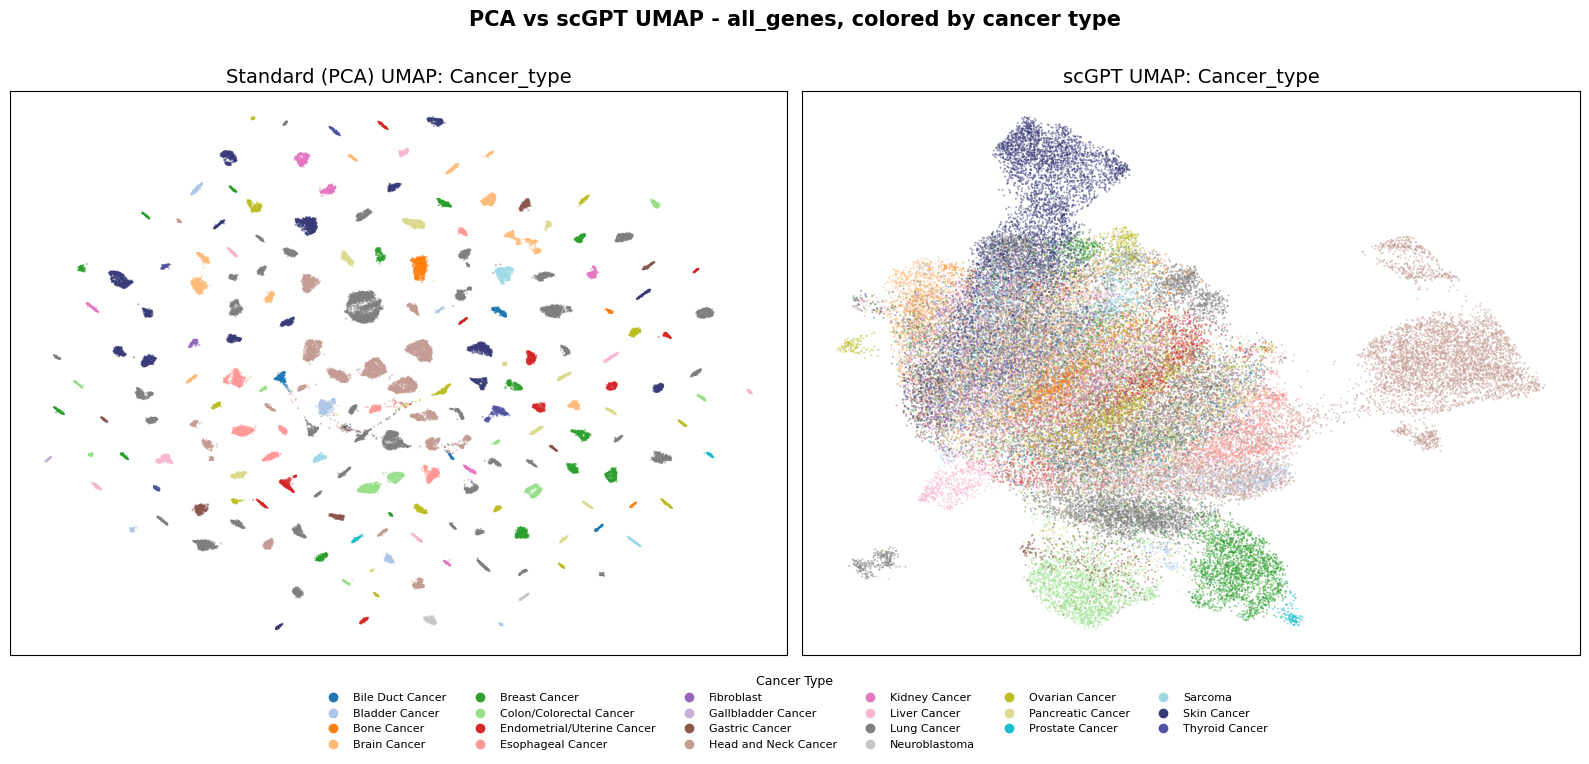

In [10]:
import sys
from pathlib import Path
import numpy as np, anndata as ad_lib, scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.layout import PipelinePaths
# Named for the subdirectory it actually writes to. It used to be the flat outputs/ root with
# 'embeddings' re-appended at each call site, so the next write added here would have landed
# in the root (audit #24, 13.08.2026). Resolved paths are unchanged.
OUT_EMB = ROOT / 'notebooks' / 'outputs' / 'embeddings'; OUT_EMB.mkdir(parents=True, exist_ok=True)

VARIANT, SEED = 'all_genes', 42         # full transcriptome; seed 42 project-wide (was 0, which matched the original slide)
# obsm only (backed read keeps the big .X on disk)
src = sc.read_h5ad(PipelinePaths.build(None, VARIANT).targets_h5ad, backed='r')
a = ad_lib.AnnData(X=np.zeros((src.n_obs, 1), dtype='float32'), obs=src.obs.copy())
a.obsm['X_pca'] = np.asarray(src.obsm['X_pca'], dtype='float32')
a.obsm['X_scGPT'] = np.asarray(src.obsm['X_scGPT'], dtype='float32')

coords = {}
for rep in ['X_pca', 'X_scGPT']:
    nk = f'nn_{rep}'
    sc.pp.neighbors(a, use_rep=rep, n_neighbors=15, random_state=SEED, key_added=nk)
    sc.tl.umap(a, random_state=SEED, neighbors_key=nk)
    coords[rep] = a.obsm['X_umap'].copy()

cats = sorted(a.obs['Cancer_type'].astype(str).unique())
pal = plt.colormaps['tab20'].colors + plt.colormaps['tab20b'].colors
colmap = {c: pal[i % len(pal)] for i, c in enumerate(cats)}
cvec = a.obs['Cancer_type'].astype(str).map(colmap).to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(16, 7.5))
for axx, rep, t in [(ax[0], 'X_pca', 'Standard (PCA) UMAP: Cancer_type'),
                    (ax[1], 'X_scGPT', 'scGPT UMAP: Cancer_type')]:
    U = coords[rep]
    axx.scatter(U[:, 0], U[:, 1], c=cvec, s=2, alpha=0.5, linewidths=0)
    axx.set_title(t, fontsize=14); axx.set_xticks([]); axx.set_yticks([])
h = [Line2D([0], [0], marker='o', ls='', ms=6, color=colmap[c]) for c in cats]
fig.legend(h, cats, title='Cancer Type', loc='lower center', ncol=6, fontsize=8,
           title_fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f'PCA vs scGPT UMAP - {VARIANT}, colored by cancer type', fontsize=15, fontweight='bold')
fig.tight_layout(rect=[0, 0.10, 1, 0.97])
fig.savefig(OUT_EMB / 'umap_cancertype_pca_vs_scgpt.png', dpi=300, bbox_inches='tight'); plt.show()

### 8b · Full sweep grid

/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/selin/PycharmProjects/OncoTox/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


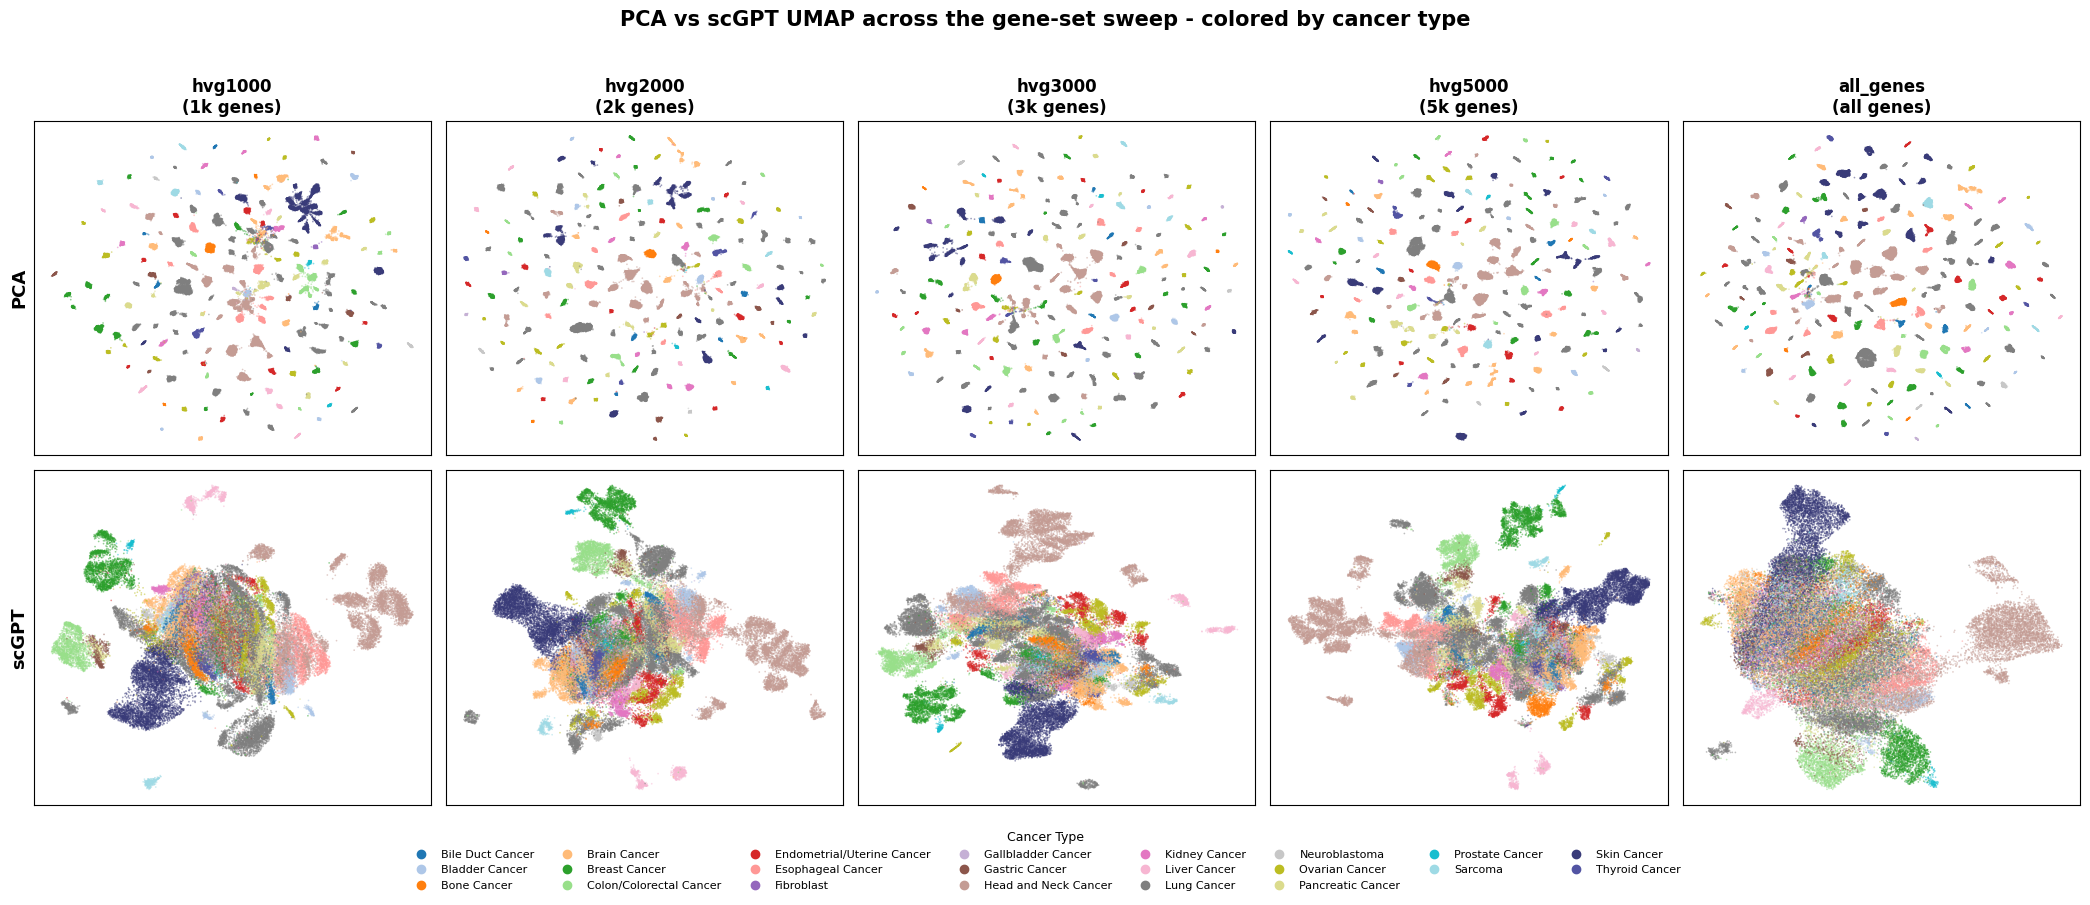

In [11]:
VARIANTS = ['hvg1000', 'hvg2000', 'hvg3000', 'hvg5000', 'all_genes']
REPS = ['X_pca', 'X_scGPT']

coords, cancer, present = {}, None, []
for v in VARIANTS:
    p = PipelinePaths.build(None, v).targets_h5ad
    if not Path(p).exists():
        print('skip', v, '(missing)'); continue
    src = sc.read_h5ad(p, backed='r')
    a = ad_lib.AnnData(X=np.zeros((src.n_obs, 1), dtype='float32'), obs=src.obs.copy())
    for rep in REPS:
        a.obsm[rep] = np.asarray(src.obsm[rep], dtype='float32')
    if cancer is None:
        cancer = a.obs['Cancer_type'].astype(str).to_numpy()
    for rep in REPS:
        nk = f'nn_{rep}'
        sc.pp.neighbors(a, use_rep=rep, n_neighbors=15, random_state=SEED, key_added=nk)
        sc.tl.umap(a, random_state=SEED, neighbors_key=nk)
        coords[(v, rep)] = a.obsm['X_umap'].copy()
    present.append(v); del a, src

cats = sorted(np.unique(cancer))
pal = plt.colormaps['tab20'].colors + plt.colormaps['tab20b'].colors
colmap = {c: pal[i % len(pal)] for i, c in enumerate(cats)}
cvec = np.array([colmap[c] for c in cancer])
glabel = {'hvg1000': '1k', 'hvg2000': '2k', 'hvg3000': '3k', 'hvg5000': '5k', 'all_genes': 'all'}

fig, axes = plt.subplots(2, len(present), figsize=(4.2 * len(present), 9), squeeze=False)
for j, v in enumerate(present):
    for i, rep in enumerate(REPS):
        ax = axes[i][j]; U = coords[(v, rep)]
        ax.scatter(U[:, 0], U[:, 1], c=cvec, s=1.5, alpha=0.5, linewidths=0)
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_title(f'{v}\n({glabel.get(v, v)} genes)', fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel({'X_pca': 'PCA', 'X_scGPT': 'scGPT'}[rep], fontsize=13, fontweight='bold')
h = [Line2D([0], [0], marker='o', ls='', ms=6, color=colmap[c]) for c in cats]
fig.legend(h, cats, title='Cancer Type', loc='lower center', ncol=8, fontsize=8,
           title_fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('PCA vs scGPT UMAP across the gene-set sweep - colored by cancer type',
             fontsize=15, fontweight='bold')
fig.tight_layout(rect=[0, 0.08, 1, 0.96])
fig.savefig(OUT_EMB / 'umap_sweep_cancertype.png', dpi=200, bbox_inches='tight'); plt.show()

## 9 · Gene-set sweep — performance against gene count

| | |
|---|---|
| **in** | all five variants' targets; `cv_evaluate` per (variant, representation) |
| **out** | `hvg_sweep_auc.csv`, `hvg_sweep_auc_curve.png` |

Trains one model per (variant, representation) under the project's own CV and plots the result
against gene-set size: how many genes does the model actually need?

**Why `counts_h5ad` is passed per variant.** Each variant's PCA must be refitted inside each fold on
that fold's fitting cells, from *that variant's own* counts — the gene sets differ by construction, so
a shared counts file would project one variant through another's genes.

**Why it retrains rather than reading a cache.** A cached sweep is a replay: it would report numbers
from whatever code last ran, under a heading that says this run produced them.

In [12]:
# --- §9 setup: self-contained, since the cells above never import the training stack ---
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, scanpy as sc, matplotlib.pyplot as plt
from scripts.layout import PipelinePaths
from scripts.training.train_multitask import cv_evaluate
from scripts.training.training_utils import TrainConfig

OUT_SWEEP = ROOT / 'notebooks' / 'outputs' / 'embeddings'
SWEEP_CSV = OUT_SWEEP / 'hvg_sweep_auc.csv'
SWEEP_PNG = OUT_SWEEP / 'hvg_sweep_auc_curve.png'

# Explicit, NOT inherited from layout.DEFAULT_CTRP_SCORE: the cache and the compute branch must
# agree on the target, or a recompute silently overwrites one target's numbers with another's.
SCORE = 'auc_cc'
SWEEP_VARIANTS = ['hvg1000', 'hvg2000', 'hvg3000', 'hvg5000', 'all_genes']
SWEEP_REPS = ['X_pca', 'X_scGPT']
N_CV_SPLITS, EPOCHS, SWEEP_SEED = 5, 50, 42
# True since 13.08.2026 (Selin, Gate 2): R5 is a REAL regeneration, not a cache read.
# Was False, which loads outputs/embeddings/.../hvg_sweep_auc.csv when present. That cache does not
# currently exist, so this flag was already falling through to a retrain -- but it would have started
# reusing the moment one run wrote it, and the reuse prints "Loaded ... (set RECOMPUTE_SWEEP=True to
# rerun)", which reads as reassurance rather than as a warning. Cost, stated: §9 trains one model per
# variant in the sweep.
RECOMPUTE_SWEEP = True

# weight_decay=0.0 (Selin, 12.08.2026): under AdamW the old 1e-3 does nothing, so
# passing it would state a setting the optimizer ignores. See TrainConfig.
sweep_config = TrainConfig(epochs=EPOCHS, lr=1e-3, weight_decay=0.0, grad_clip=1.0,
                           scheduler_patience=3, early_stop_patience=10, log_every=10,
                           seed=SWEEP_SEED, loss='mse')
print(f'sweep target={SCORE}  cache={SWEEP_CSV.relative_to(ROOT)}  exists={SWEEP_CSV.exists()}')

sweep target=auc_cc  cache=notebooks/outputs/embeddings/hvg_sweep_auc.csv  exists=True


In [13]:
if not RECOMPUTE_SWEEP and SWEEP_CSV.exists():
    sweep_df = pd.read_csv(SWEEP_CSV)
    print(f'Loaded {SWEEP_CSV.relative_to(ROOT)} (set RECOMPUTE_SWEEP=True to rerun).')
else:
    rows = []
    for v in SWEEP_VARIANTS:
        pp = PipelinePaths.build(None, v, SCORE)
        if not Path(pp.targets_h5ad).exists():
            print(f'skip {v}: no {SCORE} targets yet (build with 1_preprocessing.ipynb §B).')
            continue
        # x-position = gene-set size: the HVG target for hvgN, the full convert count for all_genes.
        n_hvg = (sc.read_h5ad(pp.raw_h5ad, backed='r').n_vars if v == 'all_genes'
                 else int(v.replace('hvg', '')))
        adata = sc.read_h5ad(pp.targets_h5ad)
        for rep in SWEEP_REPS:
            # counts_h5ad is REQUIRED for any PCA rep and was missing here (fixed 13.08.2026,
            # Gate 5). This is the FOURTH call site of the same defect: Gate 1 found three in
            # 4a and fixed them, and this one was not enumerated. Under cross-validation the PCA is
            # refitted inside each fold on that fold's fitting cells, because a model input may not
            # depend on the held-out lines; without the counts file the only projection available is
            # the stored all-cells X_pca, which is exactly that leak -- so cv.fold_pca_projections_for
            # raises rather than falling back. Each variant passes ITS OWN counts file, since the
            # gene sets differ by construction across the sweep.
            folds = cv_evaluate(adata=adata, use_rep=rep, config=sweep_config,
                                n_splits=N_CV_SPLITS, drugs=None,
                                counts_h5ad=str(pp.raw_h5ad),
                                eligible_splits=('train', 'val'))
            hb = np.array([f['n_beats'] for f in folds], float)
            vm = np.array([f['best_val_mse'] for f in folds], float)
            dl = np.array([f['model_mean_mse'] - f['baseline_mean_mse'] for f in folds], float)
            rows.append({'variant': v, 'n_hvg': n_hvg, 'rep': rep, 'score': SCORE,
                         'heads_beat_mean': hb.mean(), 'heads_beat_std': hb.std(),
                         'delta_mean': dl.mean(), 'delta_std': dl.std(),
                         'val_mse_mean': vm.mean(), 'n_total': folds[0]['n_total']})
        del adata
    sweep_df = pd.DataFrame(rows)
    if not sweep_df.empty:
        SWEEP_CSV.parent.mkdir(parents=True, exist_ok=True)
        sweep_df.to_csv(SWEEP_CSV, index=False)
sweep_df

  fold 1: PCA fitted on 27516 cells -> (53513, 512)
  fold 2: PCA fitted on 28668 cells -> (53513, 512)
  fold 3: PCA fitted on 26111 cells -> (53513, 512)
  fold 4: PCA fitted on 27700 cells -> (53513, 512)
  fold 5: PCA fitted on 27137 cells -> (53513, 512)
Loaded 27516 cells for the 'custom-mask' set. K=534 drugs | mean drugs/cell=459.6 | min drug coverage=7110 cells | max drug coverage=27516 cells.
Loaded 5210 cells for the 'custom-mask' set. K=534 drugs | mean drugs/cell=450.7 | min drug coverage=1041 cells | max drug coverage=5210 cells.
Loaded 8185 cells for the 'custom-mask' set. K=534 drugs | mean drugs/cell=456.7 | min drug coverage=1246 cells | max drug coverage=8185 cells.
[cv1/5_X_pca] Training on device: mps
[cv1/5_X_pca] Multi-task mode detected (masked MSE).
[cv1/5_X_pca] Weight decay 0 on 107904 weight parameters; 1110 bias/norm parameters exempt.
[cv1/5_X_pca] Epoch [01/50] | Train MSE: 0.0501 | Val MSE: 0.0094 | LR: 1.0e-03  <- best
  best : darinaparsin:0.000(n=2585

,variant,n_hvg,rep,score,heads_beat_mean,heads_beat_std,delta_mean,delta_std,val_mse_mean,n_total
0,hvg1000,1000,X_pca,auc_cc,278.2,28.575514,-0.000254,0.000116,0.010329,534
1,hvg1000,1000,X_scGPT,auc_cc,300.2,26.573671,-0.000489,0.000200,0.010143,534
2,hvg2000,2000,X_pca,auc_cc,280.8,18.519179,-0.000283,0.000097,0.010344,534
3,hvg2000,2000,X_scGPT,auc_cc,301.8,17.497428,-0.000488,0.000131,0.010151,534
4,hvg3000,3000,X_pca,auc_cc,278.8,26.731255,-0.000308,0.000090,0.010300,534
5,hvg3000,3000,X_scGPT,auc_cc,288.2,36.602732,-0.000469,0.000284,0.010179,534
6,hvg5000,5000,X_pca,auc_cc,284.0,28.474550,-0.000379,0.000134,0.010335,534
7,hvg5000,5000,X_scGPT,auc_cc,293.6,25.842600,-0.000456,0.000246,0.010235,534
8,all_genes,22722,X_pca,auc_cc,278.4,33.850258,-0.000334,0.000137,0.010409,534
9,all_genes,22722,X_scGPT,auc_cc,303.8,34.631777,-0.000416,0.000233,0.010201,534


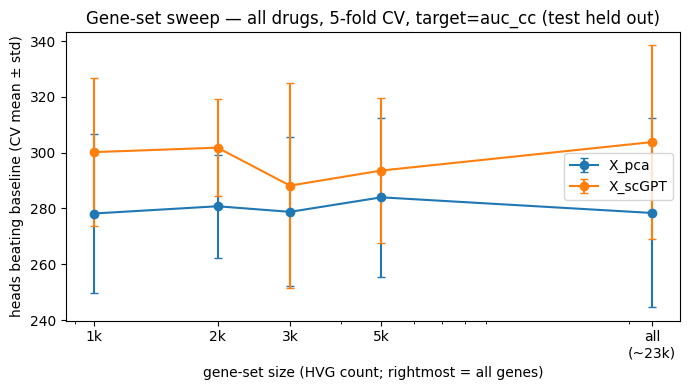

In [14]:
if sweep_df.empty or sweep_df['variant'].nunique() < 2:
    print('Need >=2 variants for the sweet-spot curve. Build them in 1_preprocessing.ipynb §B, then re-run.')
else:
    ticks = sorted(sweep_df['n_hvg'].unique())
    labels = [f'{t//1000}k' if t < 20000 else f'all\n(~{t/1000:.0f}k)' for t in ticks]
    fig, ax = plt.subplots(figsize=(7, 4))
    for rep in SWEEP_REPS:
        d = sweep_df[sweep_df.rep == rep].sort_values('n_hvg')
        ax.errorbar(d['n_hvg'], d['heads_beat_mean'], yerr=d['heads_beat_std'],
                    marker='o', capsize=3, label=rep)
    ax.set_xscale('log'); ax.set_xticks(ticks); ax.set_xticklabels(labels)
    ax.set_xlabel('gene-set size (HVG count; rightmost = all genes)')
    ax.set_ylabel('heads beating baseline (CV mean ± std)')
    ax.set_title(f'Gene-set sweep — all drugs, 5-fold CV, target={SCORE} (test held out)')
    ax.legend()
    SWEEP_PNG.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout(); fig.savefig(SWEEP_PNG, dpi=150); plt.show()


## 10 · Does scGPT see the gene set it was given?

| | |
|---|---|
| **out** | `scgpt_nonzero_per_cell.npz`, and where the model's input cap binds |

scGPT takes a fixed maximum number of tokens per cell. If a cell has more non-zero genes than that
cap, the rest are never seen — so a variant can nominally carry 22,722 genes while the model receives
far fewer.

**Why this decides how §9 is read.** If the cap binds for the larger variants, their extra genes
never reach the encoder, and a flat sweep would say nothing about whether those genes matter.

### 10a · Are the HVG variants nested?

Whether `hvg1000 ⊂ hvg2000 ⊂ hvg3000 ⊂ hvg5000`. If they are, the sweep is a single axis; if not,
each point is a different gene set and the curve is not a sweep.

In [15]:
# Gene sets come from `convert` (post-HVG, pre-OOV): nesting is a property of the HVG filter,
# not of scGPT's vocabulary.
SWEEP_VARIANTS = ['hvg1000', 'hvg2000', 'hvg3000', 'hvg5000', 'all_genes']

gene_sets = {v: set(load(v, 'convert').var_names) for v in SWEEP_VARIANTS}

rows = []
for smaller, larger in zip(SWEEP_VARIANTS, SWEEP_VARIANTS[1:]):
    outside = gene_sets[smaller] - gene_sets[larger]
    rows.append({'smaller': smaller, 'genes': len(gene_sets[smaller]), 'larger': larger,
                 'not contained in larger': len(outside), 'nested': not outside})
pd.DataFrame(rows)

,smaller,genes,larger,not contained in larger,nested
0,hvg1000,1000,hvg2000,0,True
1,hvg2000,2000,hvg3000,0,True
2,hvg3000,3000,hvg5000,0,True
3,hvg5000,5000,all_genes,0,True


### 10b · Non-zero genes per cell, and where the cap binds

| | |
|---|---|
| **out** | the distribution per variant, against the model's token cap |

Regenerated rather than read from cache: the counts depend on the gene set and on the symbol
resolution, both of which have changed.

In [16]:
import h5py

CAP = 1200                 # scGPT max_length (gen_embeds.py); == scGPT_human/args.json "max_seq_len"
GENE_BUDGET = CAP - 1      # <cls> takes one slot and keep_first_n_tokens=1 protects it -> 1,199 genes
CHUNK = 2048               # 2,048 x 20,570 x 8 B ~ 340 MB per block for all_genes
# True since 13.08.2026 (Selin, Gate 2), and this one was actively biting. The cache
# outputs/embeddings/scgpt_nonzero_per_cell.npz IS committed and present, so with False this cell
# loaded per-cell non-zero counts computed from embeddings that PREDATE the gene-symbol repair
# (4,576 -> 4,765 in-vocabulary genes for hvg5000; 4,704 was the pre-sweep prediction) and printed "Loaded ... (set RECOMPUTE_COUNTS=True
# to rerun)". After R2 those numbers describe a gene set the pipeline no longer uses, and nothing in
# the output would have said so -- notebooks/outputs/README.md meanwhile promised this directory is
# "regenerated by verify_variants at R5", which under the old default it was not.
RECOMPUTE_COUNTS = True

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
COUNTS_NPZ = ROOT / 'notebooks' / 'outputs' / 'embeddings' / 'scgpt_nonzero_per_cell.npz'

if not RECOMPUTE_COUNTS and COUNTS_NPZ.exists():
    counts = {v: a for v, a in np.load(COUNTS_NPZ).items()}
    print(f'Loaded {COUNTS_NPZ.relative_to(ROOT)} (set RECOMPUTE_COUNTS=True to rerun).')
else:
    counts = {}
    for v in SWEEP_VARIANTS:
        with h5py.File(DATA_ROOT / v / FILES['embeddings'], 'r') as f:
            X = f['X']                       # dense (n_cells, n_invocab_genes), verified for all five
            n_cells, n_genes = X.shape
            c = np.empty(n_cells, dtype=np.int32)
            for i in range(0, n_cells, CHUNK):
                c[i:i + CHUNK] = np.count_nonzero(X[i:i + CHUNK], axis=1)
        counts[v] = c
        print(f'{v:>10}: {n_genes:>6,} in-vocab genes | mean {c.mean():>6.0f} expressed/cell '
              f'| {(c >= CAP).sum():>6,} cells at or above the cap')
    COUNTS_NPZ.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(COUNTS_NPZ, **counts)
    print(f'Cached to {COUNTS_NPZ.relative_to(ROOT)}')

   hvg1000:    971 in-vocab genes | mean    127 expressed/cell |      0 cells at or above the cap
   hvg2000:  1,934 in-vocab genes | mean    281 expressed/cell |      0 cells at or above the cap
   hvg3000:  2,867 in-vocab genes | mean    415 expressed/cell |      0 cells at or above the cap
   hvg5000:  4,765 in-vocab genes | mean    673 expressed/cell |    174 cells at or above the cap
 all_genes: 21,332 in-vocab genes | mean   3723 expressed/cell | 53,513 cells at or above the cap
Cached to notebooks/outputs/embeddings/scgpt_nonzero_per_cell.npz


### 10c · What scGPT actually received

The effective gene count per variant — nominal size, minus out-of-vocabulary, minus what the cap
truncates. This is the number §9's x-axis should be read against, not the variant's name.

In [17]:
# n_vars per variant: shape only, no data read.
n_invocab = {}
for v in SWEEP_VARIANTS:
    with h5py.File(DATA_ROOT / v / FILES['embeddings'], 'r') as f:
        n_invocab[v] = f['X'].shape[1]

rows = []
for v in SWEEP_VARIANTS:
    c = counts[v]
    capped = c >= CAP
    rows.append({
        'variant': v,
        'genes after HVG': len(gene_sets[v]),
        'in scGPT vocab': n_invocab[v],
        'expressed/cell: min': int(c.min()),
        'median': int(np.median(c)),
        'mean': round(float(c.mean())),
        'max': int(c.max()),
        'cells >= cap': int(capped.sum()),
        '% cells capped': round(100 * float(capped.mean()), 3),
        'genes actually seen (mean)': round(float(np.minimum(c, GENE_BUDGET).mean())),
        '% kept, capped cells': (round(100 * float(np.median(GENE_BUDGET / c[capped])), 1)
                                 if capped.any() else None),
    })
pd.DataFrame(rows).set_index('variant')

,genes after HVG,in scGPT vocab,expressed/cell: min,median,mean,max,cells >= cap,% cells capped,genes actually seen (mean),"% kept, capped cells"
variant,,,,,,,,,,
hvg1000,1000,971,38,124,127,298,0,0.000,127,NaN
hvg2000,2000,1934,101,276,281,618,0,0.000,281,NaN
hvg3000,3000,2867,179,408,415,886,0,0.000,415,NaN
hvg5000,5000,4765,302,662,673,1407,174,0.325,672,96.9
all_genes,22722,21332,1937,3629,3723,8159,53513,100.000,1199,33.0
